<center><h1><font color='darkblue'>Elektrotehnički fakultet Beograd</font></h1></center>

# Drugi domaći zadatak, školska 2024/2025. godina

Luka Puco 2024/0091

<font color='red'>
Preimenovati svesku: File/Rename u drugi_domaci_ime_prezime<br>
Redovno snimati aktuelnu verziju sveske: File/Save and Checkpoint <br>
Snimati fajl: Download as Notebook (.ipynb)</font>

#### __Zadatak 1__: Model sa promenljivom brzinom
Simulirati model protoka saobraćaja koji je modelovan parcijalnom diferencijalnom jednačinom:

\begin{equation}
    \frac{\partial\rho(x,t)}{\partial t} + \frac{\partial}{\partial x}\left(v(\rho)\rho(x,t)\right) = 0
\end{equation}

u kome brzina vozila nije konstantna već zavisi od gustine (a samim tim i od koordinate $x$ i vremena $t$). 

U fajlu <font color='blue'>traffic_data.csv</font> nalaze se podaci dobijeni snimanjem protoka saobraćaja u Linkoln tunelu, koji prolazi ispod reke Hadson i povezuje Nju Džersi sa centrom Menhetna. U prvoj koloni nalazi se gustina vozila (data u jedinicama kola/milji) a u drugoj koloni njhova brzina (data u jedinicama milja/sat).

a) Koristeći se pandas bibliotekom, napraviti Python skriptu u okviru koje treba učitati .csv fajl, a zatim konvertovati jedinice u kola/kilometru (1/km) i kilometar/sat (km/h) i prikazati ovu zavisnost u okviru jednog scatter grafika. Obeležiti ose grafika. 

Text(0, 0.5, 'ro (vozila/km)')

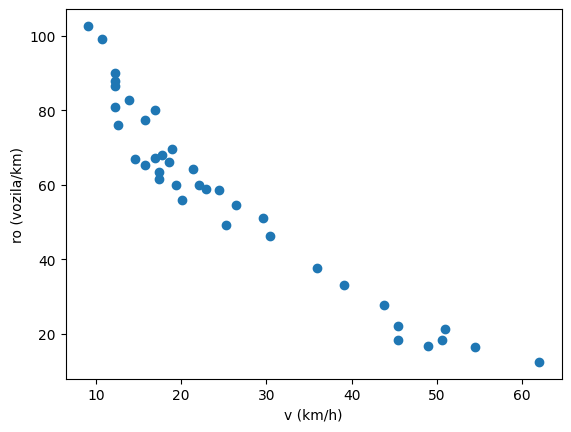

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("traffic_data.csv")
MILE_TO_KM = 1.60934
df.iloc[:, 1] = df.iloc[:, 1] * MILE_TO_KM
df.iloc[:,0]=df.iloc[:,0]/ MILE_TO_KM
plt.scatter(df.iloc[:,1], df.iloc[:,0])
plt.xlabel("v (km/h)")
plt.ylabel("ro (vozila/km)")

Grinšilds-ov model pretpostavlja linearnu zavisnost brzine od gustine i dat je sledećom linearnom funkcijom:

\begin{equation}
    v(\rho) = v_\text{m}\left(1 - \frac{\rho}{\rho_\text{m}}\right)
\end{equation}

gde je $v_\text{m}$ maksimalna brzina vozila, a $\rho_\text{m}$ maksimalna gustina vozila (kada bi sva vozila bila pozicionirana jedna iza drugog, bez razmaka). 

b) Koristeći <font color='blue'>scipy.optimize.curve_fit</font> (Python funkcija koja povlači optimalnu pravu kroz dati skup tačaka, pogledati help) pronaći koeficijente $v_\text{m}$ i $\rho_\text{m}$ koji definišu optimalnu pravu. Koeficijente pronaći u jedinicama km/h i 1/km, respektivno. Nacrtati grafik na kome su eksperimentalni podaci nacrtati crvenim tačkama, a optimalna prava plavom linijom. Obeležiti ose grafika i na grafik staviti legendu. 

(Napomena: ukoliko se čini da je dobijena maksimalna brzina vozila previše mala, treba imati na umu da u tunelu postoji rigorozno ograničenje brzine. Proveriti dobijenu vrednost iz Python modela sa realnim ograničenjem koje se može naći na linku: https://en.wikipedia.org/wiki/Lincoln_Tunnel pod stavkom “operating speed”).


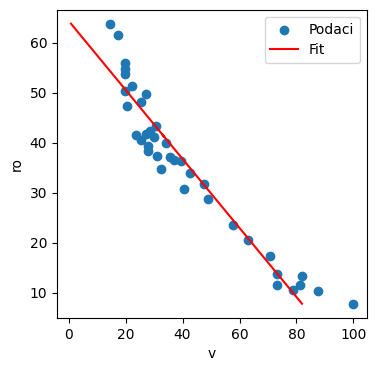

[93.1977628  64.34267208]


In [2]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def model(ro, vm, ro_max):
    return vm * (1 - ro / ro_max)

ro = df.iloc[:,0] / MILE_TO_KM
v   = df.iloc[:,1] * MILE_TO_KM
popt, pcov = curve_fit(model, ro, v)

plt.figure(figsize=(4,4))

plt.scatter(v, ro, label="Podaci")
plt.plot(model(ro, *popt), ro, color="red", label="Fit")
plt.xlabel("v")
plt.ylabel("ro")
plt.legend()
plt.show()
print(popt)


Vmax=93.19
Romax=64.34

c) Uzimajući u obzir funkcijsku zavisnost brzine od gustine, srediti jednačinu u oblik pogodan za primenu metode konačnih razlika, tako da jednačina ima formu:

\begin{equation}
    \frac{\partial\rho(x,t)}{\partial t} + c(\rho)\frac{\partial\rho(x,t)}{\partial x} = 0
\end{equation}

gde je $c(\rho)$ funkcija u kojoj kao promenljiva figuriše samo gustina $\rho$, a kao konstante maksimalna brzina $v_\text{m}$ i maksimalna gustina $\rho_\text{m}$. Napisati dobijenu funkciju $c(\rho)$:

C(ro) = Vm(1-ro/roMax)

d)	U daljem nastavku Python skripte primeniti metodu konačnih razlika za rešavanje gornje parcijalne diferencijalne jednačine koja modeluje protok saobraćaja. Na gornju jednačinu primeniti metodu konačnih razlika za sledeće parametre:

<ol>
    <li>Ukupna dužina posmatranog puta $L = 2.4$ km,</li>
    <li>Vremenski domen za rešavanje $T = 180$ sekundi,</li>
    <li>Koraci diskretizacije: $\Delta x = 0.05$ km, $\Delta t = 0.1$ s.</li>
</ol>

Za rešavanje jednačine potrebno je poznavanje početnog, odnosno graničnog uslova. Početni i granični uslov treba definisati tako da se modeluje semafor koji na koordinati $x = 0$ u trenutku $t = 0$ prelazi iz crvenog u zeleno. Pretpostavka je da je crveno svetlo na semaforu trajalo dovoljno dugo tako da se u trenutku $t = 0$ sva vozila nalaze iza semafora, a da ispred semafora nema nijednog vozila. Simulirati dan kada je na putu nije bilo velike gužve, tj. kada gustina vozila iza semafora ima vrednost $0.3\rho_\text{m}$.


Nacrtati 3D grafik zavisnosti gustine vozila $\rho$ u funkciji od $x$ i $t$. Obeležiti ose grafika. 

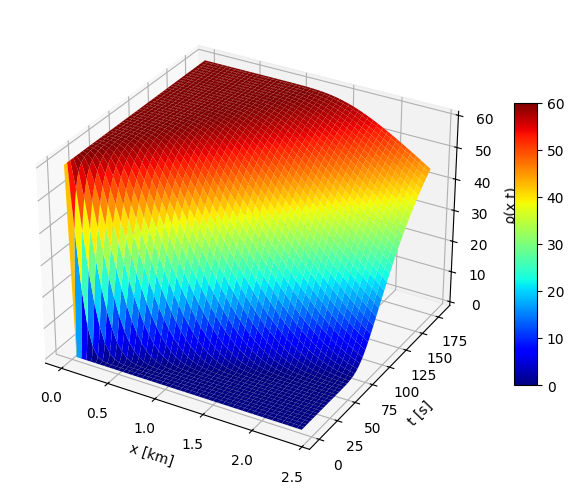

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

vm, rho_max = 90/3600, 200

def c_of_rho(rho):
    return vm * (1 - rho / rho_max)

L, T = 2.4, 180.0
dx, dt = 0.05, 0.1
x = np.arange(0, L+1e-12, dx)
t = np.arange(0, T+1e-12, dt)
nx, nt = len(x), len(t)

rho = np.zeros((nt, nx))
rho[:, 0] = 0.3 * rho_max

lam = dt / dx
for n in range(nt - 1):
    f = rho[n, :] * c_of_rho(rho[n, :])          # f(rho) = rho * c(rho)
    rho[n+1, 1:] = rho[n, 1:] - lam * (f[1:] - f[:-1])
    rho[n+1, :]  = np.clip(rho[n+1, :], 0.0, rho_max)
    rho[n+1, 0]  = 0.3 * rho_max

X, Y = np.meshgrid(x, t)
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, rho, cmap=cm.jet)
fig.colorbar(surf, shrink=0.6, aspect=12)
ax.set_xlabel('x [km]')
ax.set_ylabel('t [s]')
ax.set_zlabel('ρ(x,t)')
plt.tight_layout()
plt.show()


Nacrtati 2D grafik zavisnosti gustine vozila $\rho$ u funkciji od $x$ za tri vremenska trenutka (izabrati po želji, recimo $t = 100$, $120$ i $160$ sekudni ili neka druga tri vremenska trenutka koja bolje demonstriraju dinamiku promene gustine vozila). Obeležiti ose grafika i uneti legendu. 

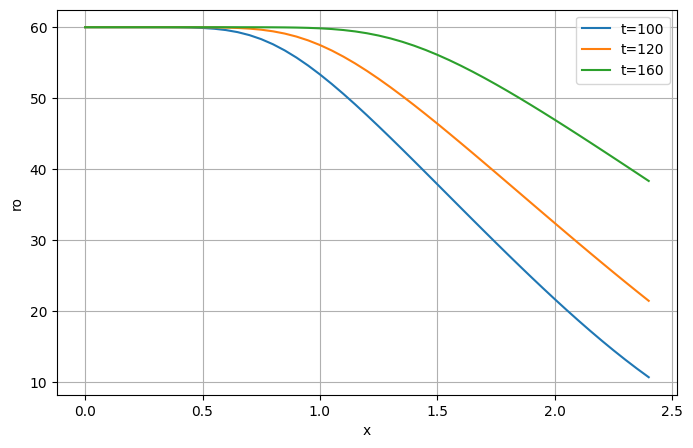

In [41]:
times = [100, 120, 160]

plt.figure(figsize=(8,5))
for time in times:
    i = np.argmin(np.abs(t - time))   # indeks najbliži traženom vremenu
    plt.plot(x, ro[i], label=f"t={time}")
plt.xlabel("x")
plt.ylabel("ro")
plt.legend()
plt.grid(True)
plt.show()


Komentarisati dobijene grafike i na osnovu njih objasniti ponašanje vozila u ovakvom modelu. 

Rezultati su očekivani: što duže traje zeleno svetlo, više vozila napušta semafor i talas gustine se širi niz put. Gustina vozila iza semafora ostaje približno konstantna, dok se neke dalje koordinate razlikuju u gustini vozila.

Diskutovati šta se dešava kada bi gužva na putu bila jako velika, odnosno kada bi gustina vozila iza semafora bila jako velika ($0.8\rho_\text{m}$). Ponoviti prethodni 3D kao i 2D grafik za promenjeni granični/početni uslov. 

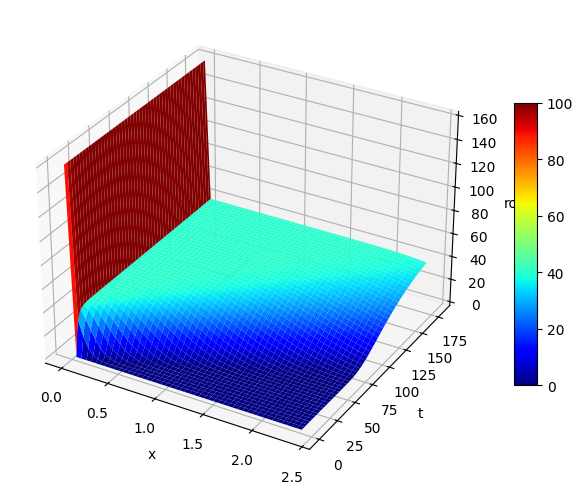

In [24]:
ro[:, 0] = 0.8 * ro_max
for n in range(nt - 1):
    f = flux(ro[n, :])
    ro[n+1, 1:] = ro[n, 1:] - lam * (f[1:] - f[:-1])
    ro[n+1, :]  = np.clip(ro[n+1, :], 0.0, ro_max)
    ro[n+1, 0]  = 0.8 * ro_max

X, Y = np.meshgrid(x, t)
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, ro, cmap=cm.jet)
fig.colorbar(surf, shrink=0.6, aspect=12)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('ro')
plt.tight_layout()
plt.show()


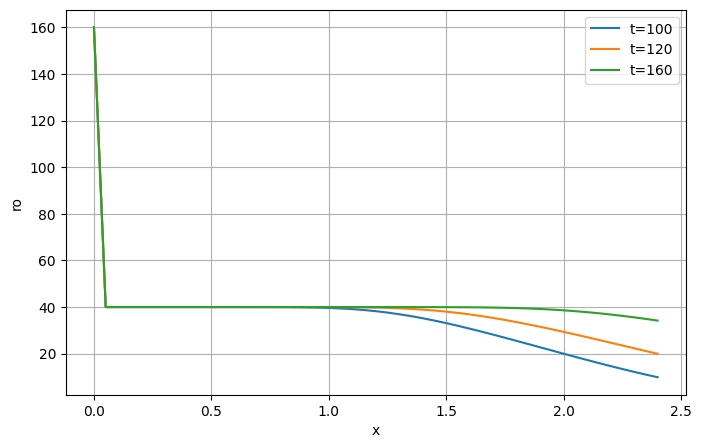

In [25]:
times = [100, 120, 160]
plt.figure(figsize=(8,5))
for time in times:
    i = np.argmin(np.abs(t - time))
    plt.plot(x, ro[i], label=f"t={time}")
plt.xlabel("x")
plt.ylabel("ro")
plt.legend()
plt.grid(True)
plt.show()


Uneti komentar.